# Part 1 – Present an Overview of Hyper-Parameter Optimization: A Review of Algorithms and Applications (from the attached paper)


# Part 2- Image Classification & Hyperparameter Turning on Fashion-MNIST.

The objective of this project is to predict fashion classes such as pants, shirts, and shoes from grayscale images. This guided project is practical and directly applicable to the fashion industry. You can add this project to your portfolio of projects which is essential for your next job interview.
Learning Objectives
________________________________________
•	Perform data cleaning, feature engineering and visualization
•	Understand the theory and intuition behind artificial neural networks
•	Build, train and test an artificial neural network model in Keras and Tensorflow
Overview of Health Care Systems and


__Objective:__ To classify images of different pieces of clothing.

__Client & Data-Set:__ Fashion-MNIST is a dataset of Zalando's article images—consisting of a training set of 60,000 examples and a test set of 10,000 examples. Each example is a 28x28 grayscale image, associated with a label from 10 classes. 

Data-set is publicly available on kaggle and __[Zalando Fashion MNIST repository](https://github.com/zalandoresearch/fashion-mnist)__ on Github.

Fashion-MNIST is intended as direct drop-in replacement for the original MNIST dataset. It shares the same image size and structure of training and testing splits.

__Business Impact:__ E-commerce companies have lots of items for sale online which requires lots of images to be displayed on their websites, applications and on social media. And it takes lot of human power and time to separate these images into respective groups. This classifier which we are going to build helps businesses to categorize images into respective groups.

__Labels:__ Each training and test example is assigned to one of the following labels:

•	0 - T-shirt/top 
•	1 - Trouser 
•	2 - Pullover 
•	3 - Dress 
•	4 - Coat 
•	5 - Sandal 
•	6 - Shirt 
•	7 - Sneaker 
•	8 - Bag 
•	9 - Ankle boot 

# TASK #1: UNDERSTAND THE PROBLEM STATEMENT  

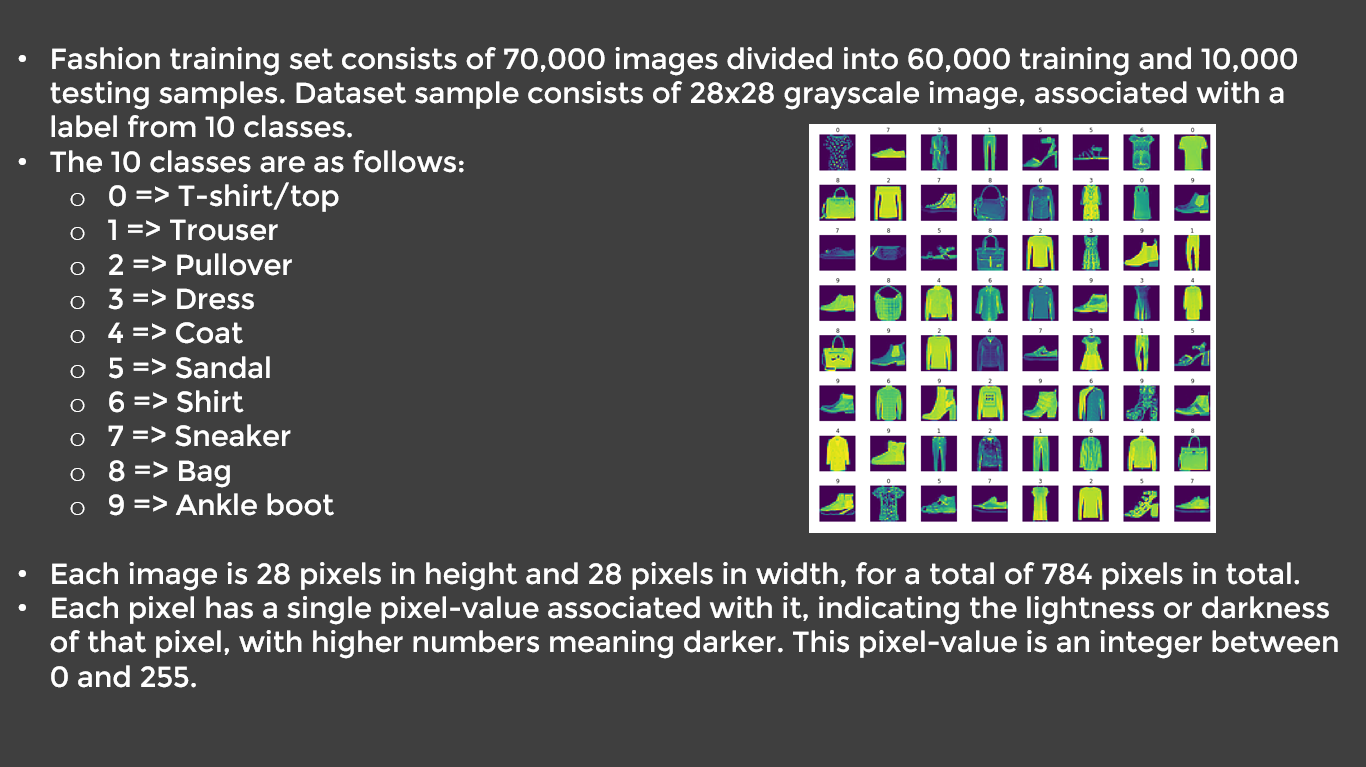

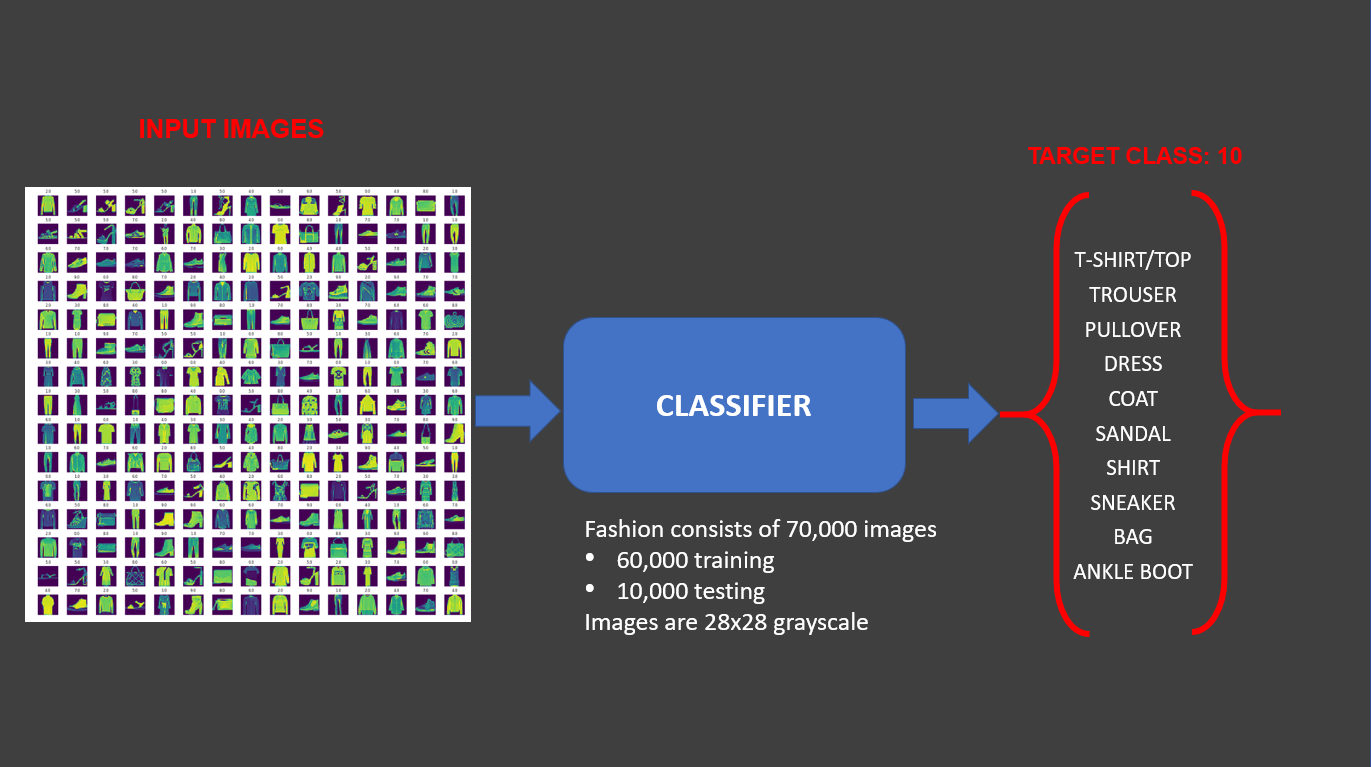

In [1]:
import numpy as np
import pandas as pd
import itertools
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.utils import shuffle
from sklearn.metrics import confusion_matrix, classification_report
import tensorflow as tf
import keras
from keras.models import Sequential
from tensorflow.keras.utils import to_categorical  # tensorflow.

# from keras.utils.vis_utils import plot_model
from tensorflow.keras.utils import plot_model
from tensorflow.keras.optimizers import Adam  # tensorflow.
from keras.layers import (
    Dense,
    Activation,
    Dropout,
    Flatten,
    Conv2D,
    MaxPooling2D,
    BatchNormalization,
    ZeroPadding2D,
)
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from keras.callbacks import EarlyStopping

# TASK #2: IMPORT LIBRARIES AND DATASETS

In [2]:
# Import required libraries
import tensorflow as tf

# Load the Fashion MNIST dataset
fashion_mnist = tf.keras.datasets.fashion_mnist
(train_images, train_labels), (test_images, test_labels) = fashion_mnist.load_data()

# Verify the data shapes
print("Training set shape:", train_images.shape)
print("Training labels shape:", train_labels.shape)
print("Test set shape:", test_images.shape)
print("Test labels shape:", test_labels.shape)

# Normalize the pixel values
train_images = train_images / 255.0
test_images = test_images / 255.0

Training set shape: (60000, 28, 28)
Training labels shape: (60000,)
Test set shape: (10000, 28, 28)
Test labels shape: (10000,)


In [3]:
import matplotlib.pyplot as plt
from jupyterthemes import jtplot

jtplot.style(theme = 'monokai', context = 'notebook', ticks = True, grid = False)
# setting the style of the notebook to be monokai theme
# this line of code is important to ensure that we are able to see the x and y axes clearly
# If you don't run this code line, you will notice that the xlabel and ylabel on any plot is black on black and it will be hard to see them.

In [4]:
# Use the same dataset made readily available by keras Using the following lines of code:


**PRACTICE OPPORTUNITY #1:**
- **Check out the sizes of both training and testing datasets**

# TASK #3: PERFORM DATA VISUALIZATION

In [5]:
# Select a sample image and visualize it


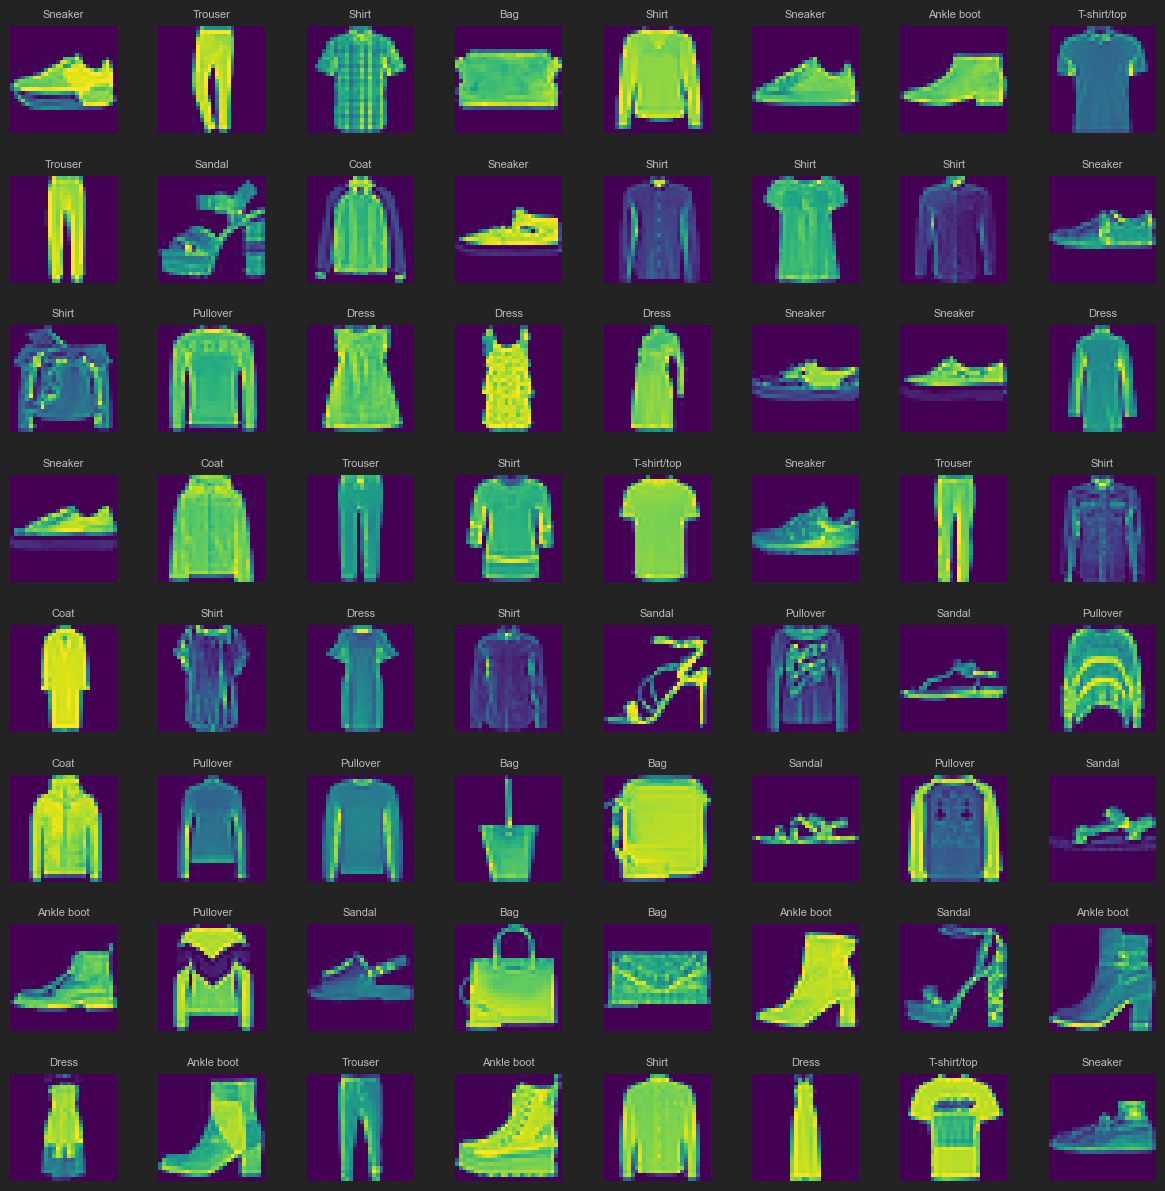

In [6]:
# Define class names for better readability
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

# Create a grid of subplots
W_grid = 8
L_grid = 8

fig, axes = plt.subplots(L_grid, W_grid, figsize=(15, 15))
axes = axes.ravel()

n_training = len(train_images)

# Select random samples to plot
for i in range(0, L_grid * W_grid):
    # Select a random image
    index = np.random.randint(0, n_training)
    
    # Display the image
    axes[i].imshow(train_images[index])
    
    # Add title with class name
    axes[i].set_title(class_names[train_labels[index]], fontsize=8)
    
    # Remove axes ticks
    axes[i].axis('off')

plt.subplots_adjust(hspace=0.4)
plt.show()

**PRACTICE OPPORTUNITY #2:**
- **Plot a grid containing 144 images and perform a sanity check on the data** 

Data sanity checks:
1. Image value range: Min: 0.0, Max: 1.0
2. Number of classes: 10
3. Class distribution:
   T-shirt/top: 6000 images (10.0%)
   Trouser: 6000 images (10.0%)
   Pullover: 6000 images (10.0%)
   Dress: 6000 images (10.0%)
   Coat: 6000 images (10.0%)
   Sandal: 6000 images (10.0%)
   Shirt: 6000 images (10.0%)
   Sneaker: 6000 images (10.0%)
   Bag: 6000 images (10.0%)
   Ankle boot: 6000 images (10.0%)

Distribution of displayed images:
T-shirt/top: 12 images
Trouser: 10 images
Pullover: 13 images
Dress: 12 images
Coat: 13 images
Sandal: 21 images
Shirt: 19 images
Sneaker: 12 images
Bag: 15 images
Ankle boot: 17 images


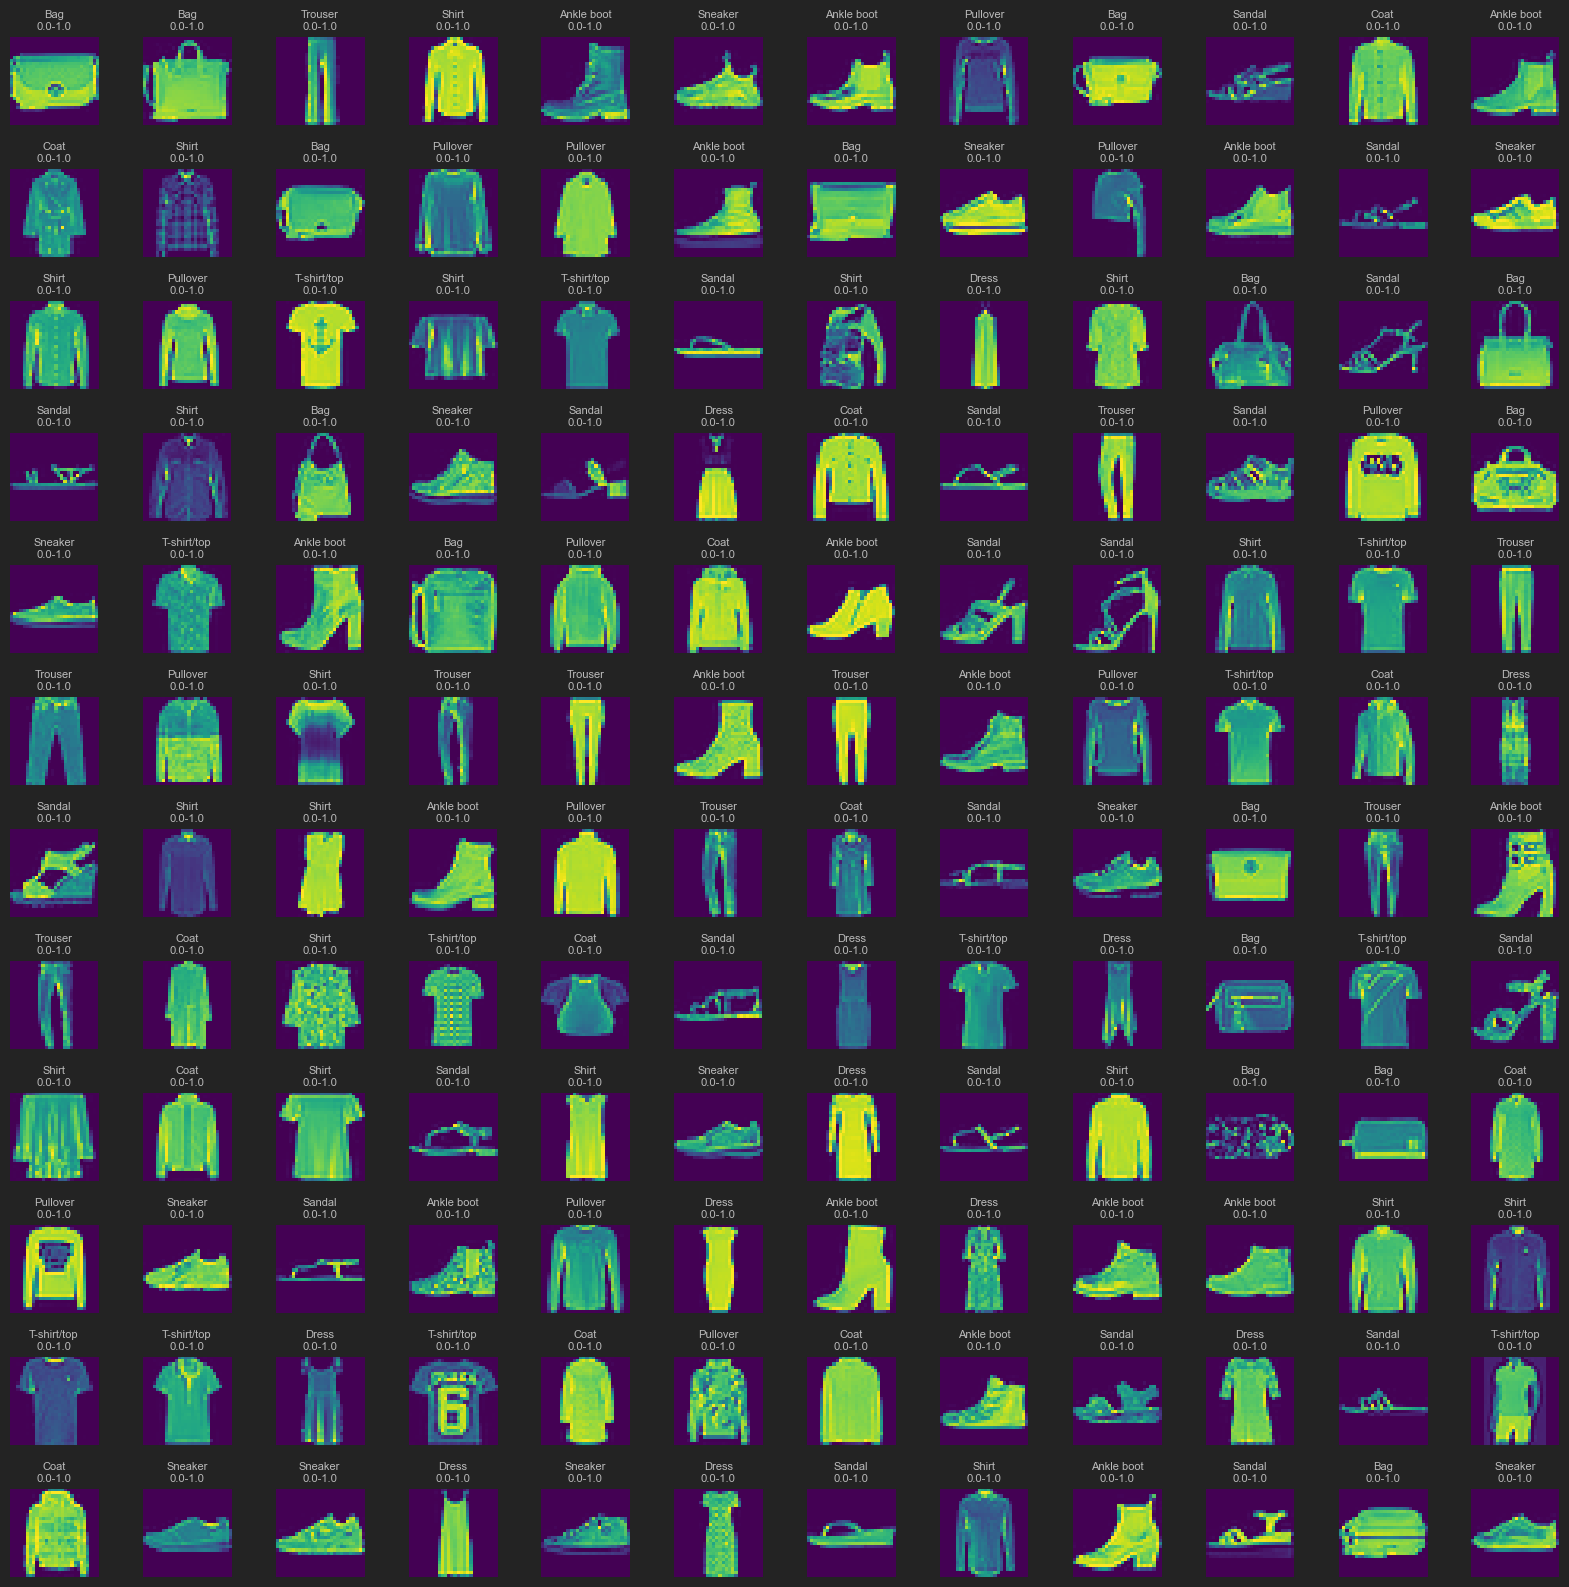

In [9]:
# Define grid dimensions for 144 images (12x12)
L_grid = 12
W_grid = 12

# Sanity checks before plotting
print("Data sanity checks:")
print("1. Image value range:", f"Min: {train_images.min()}, Max: {train_images.max()}")
print("2. Number of classes:", len(np.unique(train_labels)))
print("3. Class distribution:")
for i, class_name in enumerate(class_names):
    count = np.sum(train_labels == i)
    percentage = (count/len(train_labels)) * 100
    print(f"   {class_name}: {count} images ({percentage:.1f}%)")

# Create figure and subplots
fig, axes = plt.subplots(L_grid, W_grid, figsize=(20, 20))
axes = axes.ravel()  # Flatten the 2D array of axes

n_training = len(train_images)

# Plot random images in the grid
class_counts = np.zeros(10)  # Track number of images shown per class
for i in range(0, L_grid * W_grid):
    # Select a random image
    index = np.random.randint(0, n_training)
    class_counts[train_labels[index]] += 1
    
    # Display the image
    axes[i].imshow(train_images[index])
    
    # Add title with class name
    axes[i].set_title(f"{class_names[train_labels[index]]}\n{train_images[index].min():.1f}-{train_images[index].max():.1f}", 
                      fontsize=8)
    
    # Remove axes ticks
    axes[i].axis('off')

# Print distribution of shown images
print("\nDistribution of displayed images:")
for i, count in enumerate(class_counts):
    print(f"{class_names[i]}: {int(count)} images")

# Adjust subplot parameters for better spacing
plt.subplots_adjust(hspace=0.5, wspace=0.5)
plt.show()

# TASK #4: PREPARE THE DATA FOR TRAINING

In [10]:
# Convert labels to one-hot encoded format
number_cat = 10
y_train = tf.keras.utils.to_categorical(train_labels, number_cat)
y_test = tf.keras.utils.to_categorical(test_labels, number_cat)

# Reshape images to include channel dimension (28, 28) -> (28, 28, 1)
X_train = np.expand_dims(train_images, axis=-1)
X_test = np.expand_dims(test_images, axis=-1)

# Print shapes to verify transformations
print("Training data shapes:")
print(f"X_train: {X_train.shape} - Input images with channel dimension")
print(f"y_train: {y_train.shape} - One-hot encoded labels")
print("\nTest data shapes:")
print(f"X_test: {X_test.shape} - Input images with channel dimension")
print(f"y_test: {y_test.shape} - One-hot encoded labels")

# Verify data ranges
print("\nData ranges:")
print(f"X_train range: [{X_train.min():.3f}, {X_train.max():.3f}]")
print(f"X_test range: [{X_test.min():.3f}, {X_test.max():.3f}]")

Training data shapes:
X_train: (60000, 28, 28, 1) - Input images with channel dimension
y_train: (60000, 10) - One-hot encoded labels

Test data shapes:
X_test: (10000, 28, 28, 1) - Input images with channel dimension
y_test: (10000, 10) - One-hot encoded labels

Data ranges:
X_train range: [0.000, 1.000]
X_test range: [0.000, 1.000]


# TASK #5: BUILD A DEEP LEARNING MODEL

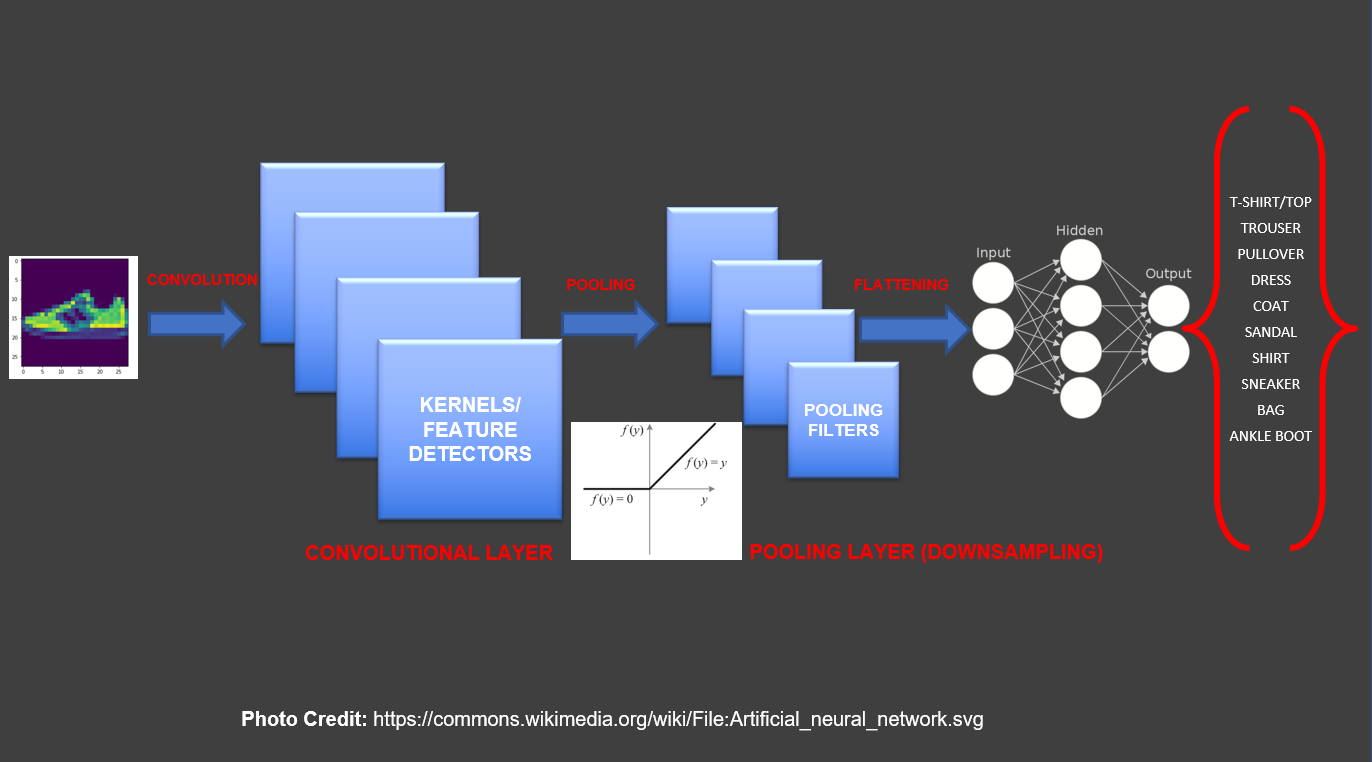

In [13]:
# Import required layers
from tensorflow.keras import datasets, layers, models

# Create CNN model using Sequential API
cnn = tf.keras.Sequential([
    # First Convolutional Block
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(28, 28, 1)),
    layers.BatchNormalization(),
    layers.MaxPooling2D(2,2),
    layers.Dropout(0.25),
    
    # Second Convolutional Block
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(2,2),
    layers.Dropout(0.25),
    
    # Third Convolutional Block
    layers.Conv2D(128, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.25),
    
    # Flatten layer to transition to dense layers
    layers.Flatten(),
    
    # Dense layers for classification
    layers.Dense(128, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.5),
    layers.Dense(10, activation='softmax')
])

# Display model architecture
cnn.summary()

c:\Users\ngovi\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 26, 26, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 11, 11, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 3, 3, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 3, 3, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 3, 3, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 1152)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 242,954 (949.04 KB)

 Trainable params: 242,250 (946.29 KB)

 Non-trainable params: 704 (2.75 KB)

# TASK #6: COMPILE AND TRAIN A DEEP LEARNING MODEL

In [14]:
cnn.compile(optimizer = tf.keras.optimizers.RMSprop(0.0001, decay = 1e-6), loss ='categorical_crossentropy', metrics =['accuracy'])

c:\Users\ngovi\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\optimizers\base_optimizer.py:86: UserWarning: Argument `decay` is no longer supported and will be ignored.
  warnings.warn(


In [15]:
X_train.shape

(60000, 28, 28, 1)

# Task 7: Perform hyperparameter tuning using Keras Tuner.
Example: Define a custom tuner class implementing Bayesian Optimization for tuning model parameters.


# TASK #8: ASSESS TRAINED THE BEST MODEL PERFORMANCE

In [ ]:
X_test.shape

In [ ]:
X_test = np.expand_dims(X_test, axis=-1)

In [ ]:
X_test.shape

In [ ]:
y_test.shape

In [ ]:
X_test = X_test.astype('float')


In [ ]:
predicted_classes = cnn.predict(X_test)

In [ ]:
predicted_classes

In [ ]:
predicted_classes=np.argmax(predicted_classes,axis=1)


In [ ]:
predicted_classes

In [ ]:
y_test

In [ ]:
y_test = y_test.argmax(1)

In [ ]:
y_test

In [ ]:
L = 5
W = 5
fig, axes = plt.subplots(L, W, figsize = (12,12))
axes = axes.ravel() # 

for i in np.arange(0, L * W):  
    axes[i].imshow(X_test[i].reshape(28,28))
    axes[i].set_title("Predicted Class = {:0.1f}\n True Class = {:0.1f}".format(predicted_classes[i], y_test[i]))
    axes[i].axis('off')

plt.subplots_adjust(wspace=0.5)

In [ ]:
from sklearn.metrics import confusion_matrix


In [ ]:
from sklearn.metrics import classification_report
num_classes = 10
target_names = ['class {}'.format(i) for i in range(num_classes)]



**PRACTICE OPPORTUNITY #3:**
- **Add a new dense layer containing 1024 neurons**
- **Increase the number of epochs**
- **Plot the model summary and determine the number of trainable parameters**
- **Retrain the model and evaluate its performance**

# GREAT JOB!

# PRACTICE OPPORTUNITIES SOLUTIONS 

**PRACTICE OPPORTUNITY #1 SOLUTION:**
- **Check out the sizes of both training and testing datasets**

In [ ]:
X_train.shape

In [ ]:
X_test.shape

In [ ]:
y_train.shape

In [ ]:
y_test.shape

**PRACTICE OPPORTUNITY #2 SOLUTION:**
- **Plot a grid containing 144 images and perform a sanity check on the data** 

In [ ]:
L = 7
W = 7
fig, axes = plt.subplots(L, W, figsize = (12,12))
axes = axes.ravel() 

for i in np.arange(0, L * W):  
    axes[i].imshow(X_test[i].reshape(28,28))
    axes[i].set_title("Prediction = {:0.1f}\n True = {:0.1f}".format(predicted_classes[i], y_test[i]))
    axes[i].axis('off')

plt.subplots_adjust(wspace=1)

**PRACTICE OPPORTUNITY #3 SOLUTION:**
- **Add a new dense layer containing 1024 neurons**
- **Increase the number of epochs**
- **Plot the model summary and determine the number of trainable parameters**
- **Retrain the model and evaluate its performance**

In [ ]:
from tensorflow.keras import datasets, layers, models
cnn = models.Sequential()

cnn.add(layers.Conv2D(32, (3,3), activation = 'relu', input_shape = (28, 28, 1)  ))
cnn.add(layers.MaxPooling2D(2,2))

cnn.add(layers.Conv2D(64, (3,3), activation = 'relu' ))
cnn.add(layers.MaxPooling2D(2,2))

cnn.add(layers.Conv2D(64, (3,3), activation = 'relu' ))

cnn.add(layers.Flatten())

cnn.add(layers.Dense(64, activation = 'relu'))
cnn.add(layers.Dense(1000, activation = 'relu'))
cnn.add(layers.Dense(10, activation = 'softmax'))
cnn.summary()